# **카트폴 DDQN - 500스텝에 도전**

In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 71.3 MB/s eta 0:00:00


환경과 모델 설정

In [ ]:
# 라이브러리 설치
import numpy as np; import random; import gymnasium as gym
from gymnasium.wrappers import TimeLimit
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, clone_model, load_model
from tensorflow.keras.layers import Dense, Input
from collections import deque
import warnings; warnings.filterwarnings('ignore')
#from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

# 환경 생성
env = gym.make("CartPole-v1")
env = TimeLimit(env, max_episode_steps=500)
n_actions=2
n_states=4

# 하이퍼 파라미터
gamma = 0.99
e = 1; e_decay = 0.995; e_min=0.05
n_sample=128
n_episodes=1000
TAU = 0.005
storage = deque(maxlen=5000)
min_step = 50; min_penalty=-100

# 예측 모델 생성
pred_model=Sequential([
    Input(shape=(n_states,)),
    Dense(16, activation="elu"),  # relu 보다 elu 활성화 함수가 성능이 더 좋을 수 있습니다.
    Dense(8, activation="elu"),
    Dense(2) ])

pred_model.compile(loss=Huber(), optimizer="adam")

# 타깃 모델 생성
target_model=clone_model(pred_model)    # 예측_모델과 동일한 구조로 설정
target_model.set_weights(pred_model.get_weights())    # 예측_모델 파라미터와 동기화

최근_보상 = deque(maxlen=5)    # 최근 보상 저장(5개)
스텝_저장=[ ]


함수 정의

In [ ]:
def soft_update(target_model, pred_model, tau):
    t_w = target_model.get_weights() # 타깃_모델의 가중치
    p_w = pred_model.get_weights()   # 예측_모델의 가중치

    new_weights = []
    for i in range(len(t_w)):        # 각 파라미터 별로 가중 평균
        new_weights.append((1 - tau) * t_w[i] + tau * p_w[i])

    target_model.set_weights(new_weights)

@tf.function
def select_action_tf(state, epsilon, pred_model, n_actions):
    state_tensor = tf.expand_dims(tf.cast(state, dtype=tf.float32), axis=0)
    q_values = pred_model(state_tensor)
    best_action = tf.argmax(q_values, axis=1, output_type=tf.int32)[0]
    random_action = tf.random.uniform(shape=(), maxval=n_actions, dtype=tf.int32)
    action = tf.where(
        tf.random.uniform(shape=()) < epsilon, random_action, best_action)
    return action

def target_bellman(state, next_state, action, reward, done):
    # 1. 모든 상태의 Q값 예측
    target = pred_model(state,training=False).numpy()
    # 2. 다음 상태의 최적 행동
    Q_next = pred_model(next_state,training=False).numpy()
    a_next = np.argmax(Q_next, axis=1)
    # 3. 벨만방정식으로 선택된 행동의 타깃 수정
    Q_target_next = target_model(next_state,training=False).numpy()
    for i in range(n_sample):
        target[i, action[i]] =reward[i]+ (gamma*Q_target_next[i, a_next[i]])*(done[i]==False)
    return target

메인 학습루프

In [ ]:
for ep in range(n_episodes):
    상태, _ = env.reset()
    steps = 0
    총_보상 = 0
    종료 = False

    while 종료==False:
        행동 = select_action_tf(상태, e, pred_model,n_actions).numpy()

        다음_상태, 보상, terminated, truncated, _ = env.step(행동)

        종료 = terminated or truncated

        steps += 1

        # 조기 실패 패널티
        if terminated and (steps < min_step):
            보상 += min_penalty

        # 경험 데이터 저장
        storage.append((상태, 행동, 보상, 다음_상태, 종료))

        총_보상 += 보상

        # 현재 상태 갱신
        상태 = 다음_상태

        # =========================
        # 경험 리플레이 학습
        # =========================

        if len(storage) > n_sample:

            # 미니배치 샘플링
            batch=random.sample(storage, n_sample)

            # 데이터 분리
            (상태_벡터, 행동_벡터, 보상_벡터, 다음_상태_벡터, 종료_벡터) = zip(*batch)

            # 어레이 변환(자료형 지정)
            상태_벡터 = np.asarray(상태_벡터, dtype=np.float32)
            행동_벡터 = np.asarray(행동_벡터, dtype=np.int32)
            보상_벡터 = np.asarray(보상_벡터, dtype=np.float32)
            다음_상태_벡터 = np.asarray(다음_상태_벡터, dtype=np.float32)
            종료_벡터 = np.asarray(종료_벡터, dtype=np.float32)

            # 타깃 Q값 계산
            Q_target=target_bellman(상태_벡터, 다음_상태_벡터, 행동_벡터, 보상_벡터, 종료_벡터)

            # 예측 모델 업데이트
            pred_model.train_on_batch(상태_벡터, Q_target)

            # 타깃 모델 업데이트
            soft_update(target_model,pred_model,TAU)

    # 탐험 비율 감소
    e = max(e_min, e * e_decay)

    # 결과 출력
    최근_보상.append(총_보상)
    최근_보상_평균 = np.mean(최근_보상)

    print(
        f"에피소드={ep:3} | "
        f"e={e:.3f} | "
        f"총_보상={총_보상:6} | "
        f"유지_스텝_수={steps:3}"
    )

    스텝_저장.append(steps)

    # 조기 종료 판정
    if 최근_보상_평균 >= 480:
        print("**조기 종료 조건 충족**")
        break

# 학습 완료 모델 저장
pred_model.save('학습_모델_200.keras')

에피소드=  0 | e=0.995 | 총_보상= -87.0 | 유지_스텝_수= 13
에피소드=  1 | e=0.990 | 총_보상= -77.0 | 유지_스텝_수= 23
에피소드=  2 | e=0.985 | 총_보상= -88.0 | 유지_스텝_수= 12
에피소드=  3 | e=0.980 | 총_보상= -80.0 | 유지_스텝_수= 20
에피소드=  4 | e=0.975 | 총_보상= -74.0 | 유지_스텝_수= 26
에피소드=  5 | e=0.970 | 총_보상= -69.0 | 유지_스텝_수= 31
에피소드=  6 | e=0.966 | 총_보상= -69.0 | 유지_스텝_수= 31
에피소드=  7 | e=0.961 | 총_보상= -83.0 | 유지_스텝_수= 17
에피소드=  8 | e=0.956 | 총_보상= -75.0 | 유지_스텝_수= 25
에피소드=  9 | e=0.951 | 총_보상= -76.0 | 유지_스텝_수= 24
에피소드= 10 | e=0.946 | 총_보상= -82.0 | 유지_스텝_수= 18
에피소드= 11 | e=0.942 | 총_보상= -85.0 | 유지_스텝_수= 15
에피소드= 12 | e=0.937 | 총_보상= -84.0 | 유지_스텝_수= 16
에피소드= 13 | e=0.932 | 총_보상= -88.0 | 유지_스텝_수= 12
에피소드= 14 | e=0.928 | 총_보상= -81.0 | 유지_스텝_수= 19
에피소드= 15 | e=0.923 | 총_보상=  52.0 | 유지_스텝_수= 52
에피소드= 16 | e=0.918 | 총_보상= -88.0 | 유지_스텝_수= 12
에피소드= 17 | e=0.914 | 총_보상= -86.0 | 유지_스텝_수= 14
에피소드= 18 | e=0.909 | 총_보상= -54.0 | 유지_스텝_수= 46
에피소드= 19 | e=0.905 | 총_보상= -64.0 | 유지_스텝_수= 36
에피소드= 20 | e=0.900 | 총_보상=  52.0 | 유지_스텝_수= 52
에피소드= 21 | e=

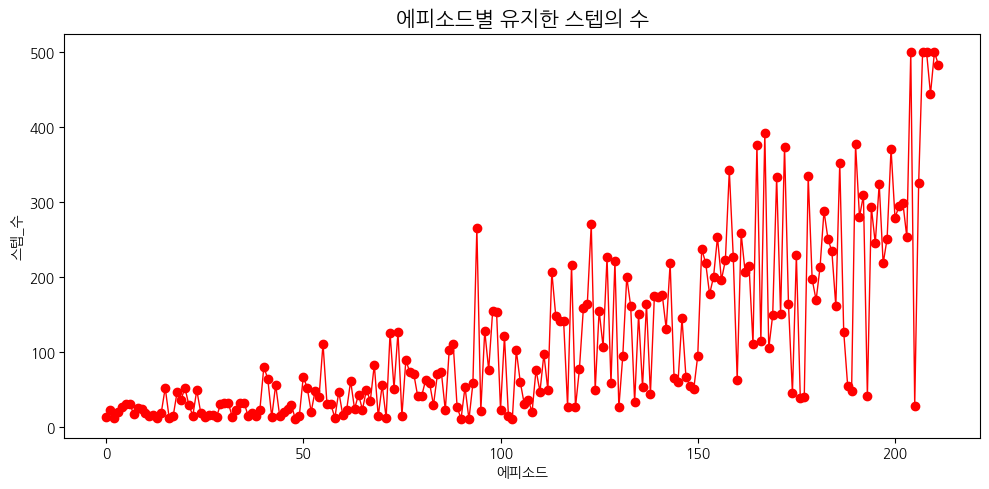

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(스텝_저장, "ro-", linewidth=1)

plt.title("에피소드별 유지한 스텝의 수", fontsize=15)
plt.xlabel("에피소드"); plt.ylabel("스텝_수")
plt.tight_layout()

plt.show()